Experimentos cargados: 45

Promedio ± desviación estándar:
  backbone.conv1        0.9512 ± 0.0833
  backbone.bn1          0.9520 ± 0.0833
  backbone.layer1.1     0.8156 ± 0.2430
  backbone.layer2.1     0.6811 ± 0.3783
  backbone.layer3.1     0.3111 ± 0.3300
  backbone.layer4.1     0.1907 ± 0.1658


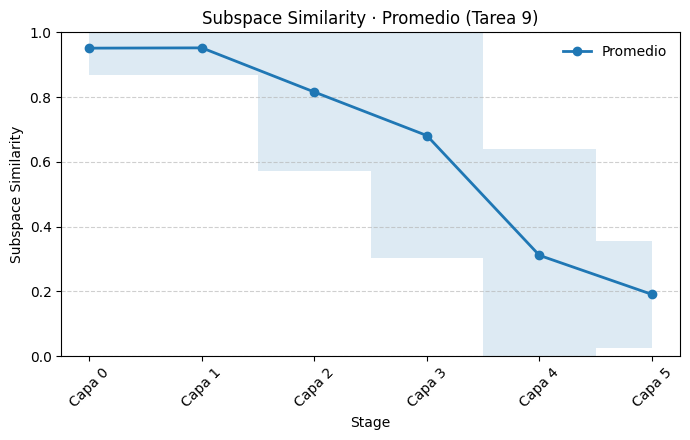

In [1]:
# Subspace Similarity – Promedio por capa (Tarea 9)
#
# Este código asume un JSON maestro con lista de 45 experimentos,
# cada uno con la clave "data" → "layers" como en tu captura.
# Si tu archivo está en otra ruta, cambia la variable `json_path`.

import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

# ─────────────────── 1. Configuración ───────────────────
json_path = Path("merged_similarity_t9.json")  # <- ajusta si es necesario
assert json_path.exists(), f"No se encontró {json_path}"

# Orden y etiquetas de las capas que queremos mostrar
STAGE_ORDER = [
    "backbone.conv1",
    "backbone.bn1",
    "backbone.layer1.1",
    "backbone.layer2.1",
    "backbone.layer3.1",
    "backbone.layer4.1",
]
ETIQUETAS = ["Capa 0", "Capa 1", "Capa 2", "Capa 3", "Capa 4", "Capa 5"]

# ─────────────────── 2. Leer y extraer datos ───────────────────
with open(json_path) as f:
    root = json.load(f)

list_layers = []
for entry in root:                        # 45 elementos
    # Cada item tiene: {"file": "...", "data": {"k": 20, "layers": {...}}}
    layers = entry.get("data", entry).get("layers", {})
    list_layers.append(layers)

print(f"Experimentos cargados: {len(list_layers)}")

# ─────────────────── 3. Promedio y desviación ───────────────────
# Intersección de capas presentes en TODOS los experimentos
common = set(list_layers[0])
for d in list_layers[1:]:
    common &= d.keys()

layers_common = [k for k in STAGE_ORDER if k in common]
raw = np.array([[d[k] for k in layers_common] for d in list_layers], dtype=float)
mean = raw.mean(axis=0)
std  = raw.std(axis=0)

print("\nPromedio ± desviación estándar:")
for k, m, s in zip(layers_common, mean, std):
    print(f"  {k:20s}  {m:.4f} ± {s:.4f}")

# ─────────────────── 4. Graficar ───────────────────
orig_x = np.arange(len(mean))
plt.figure(figsize=(7, 4.5))

# Curva promedio
plt.plot(orig_x, mean, lw=2, marker="o", label="Promedio")
# Banda de ±1 std
plt.fill_between(orig_x, mean - std, mean + std, step="mid", alpha=0.15)

plt.xticks(orig_x, ETIQUETAS[:len(mean)], rotation=45)
plt.ylim(0, 1)
plt.xlabel("Stage"); plt.ylabel("Subspace Similarity")
plt.title("Subspace Similarity · Promedio (Tarea 9)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Si quieres guardar la figura:
# plt.savefig("subspace_mean.png", dpi=300, bbox_inches="tight")
